In [1]:
import sys
import copy
sys.path.append('../src')
from utils.stock_simulation import Stock
from utils.market_simulator.market import Market
from utils.report import fast_config
from utils.simulation import save_session, load_session 

In [2]:
stock = Stock(drift=0.0, vol=0.07, origin=1.10)  # EUR/USD starts at 1.10, ~7% annual vol
stock.simulate_garch(n_days=2, dt_seconds=0.01,                                                                                                                                                           
                       alpha=0.05, beta=0.94,                                                                                                                                                               
                       lam=300,sigma_J=0.005)
market_B, market_C = fast_config.build_markets_B_C(stock)
market_maker, book = fast_config.build_market_maker_and_order_book(market_B,
                                                                   market_C)
controller = fast_config.build_controller(market_B, market_C, book, market_maker)
save_session(stock, market_B, market_C, market_maker, book, controller)
stock, market_B, market_C, market_maker, book, controller = load_session()

Coefficient annualization : 46661.333028536596
Session saved → /Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/test/../src/utils/simulation/saved_session.pkl
Session loaded ← /Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/test/../src/utils/simulation/saved_session.pkl


In [3]:
limit_step = stock.n_steps
controller.simulate(limit_step)

100%|██████████| 17280000/17280000 [04:31<00:00, 63706.34it/s]


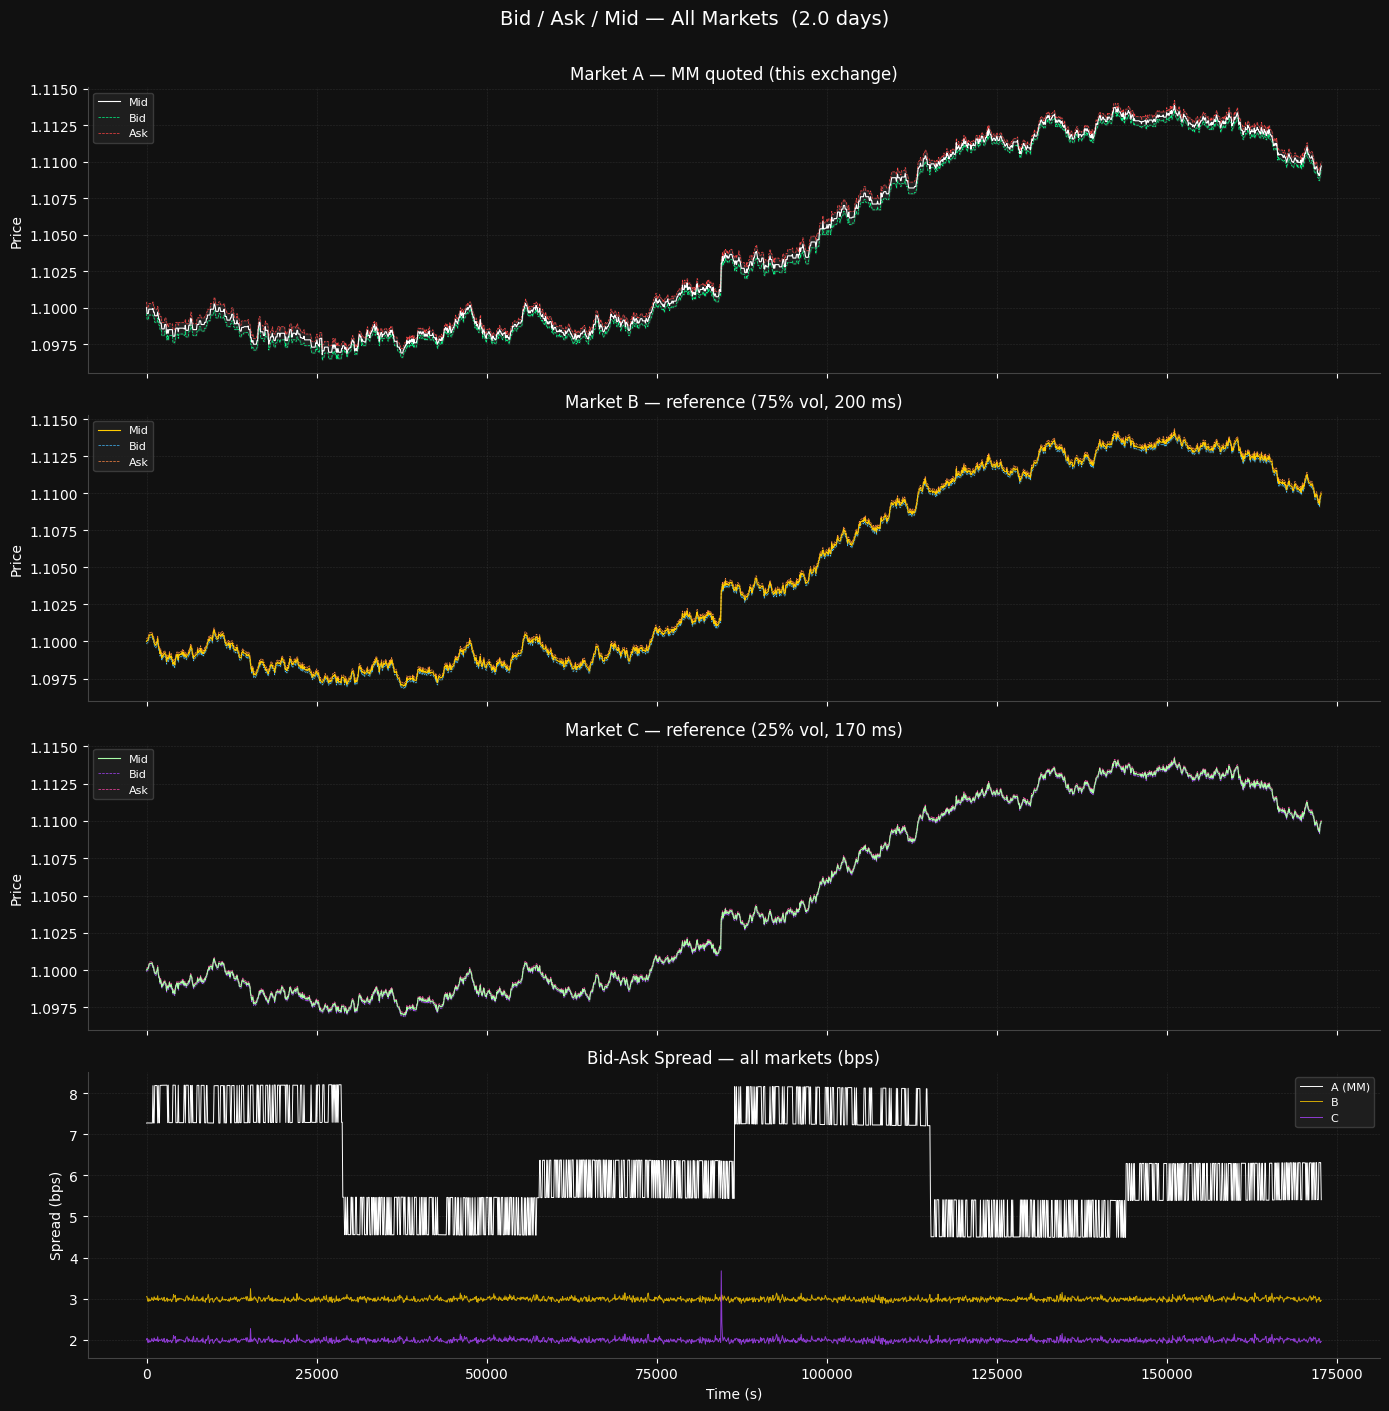

In [4]:
controller.plot_market_quotes()

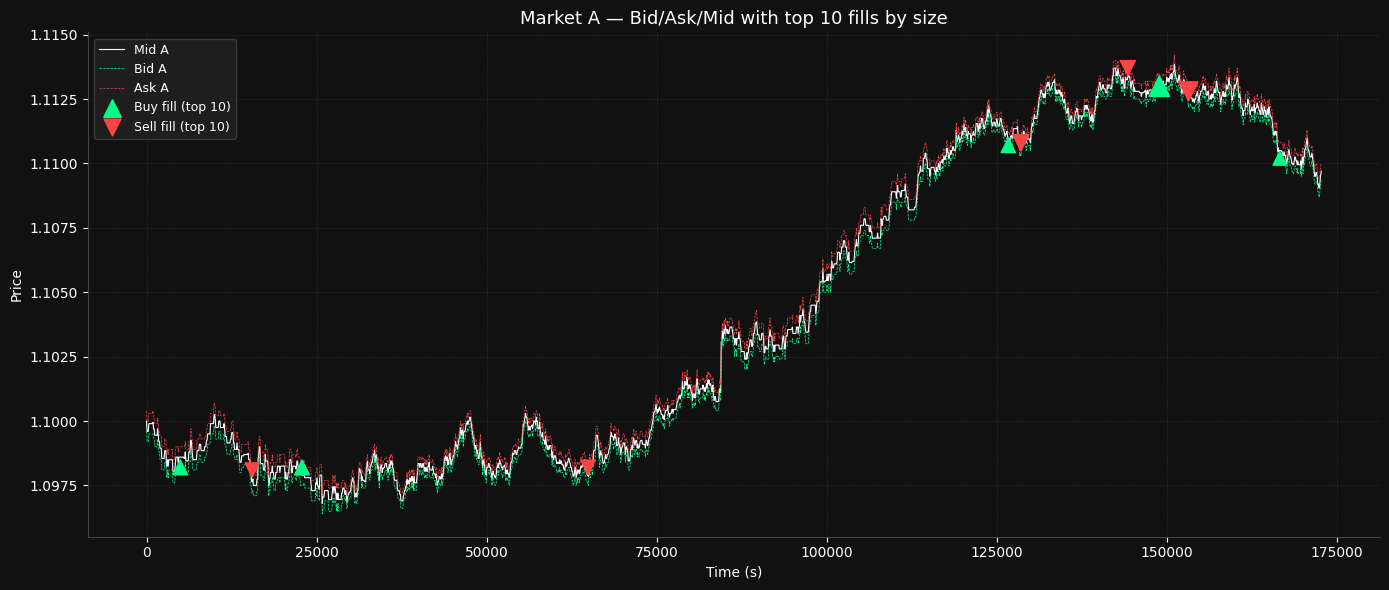

In [5]:
controller.plot_top_trades()

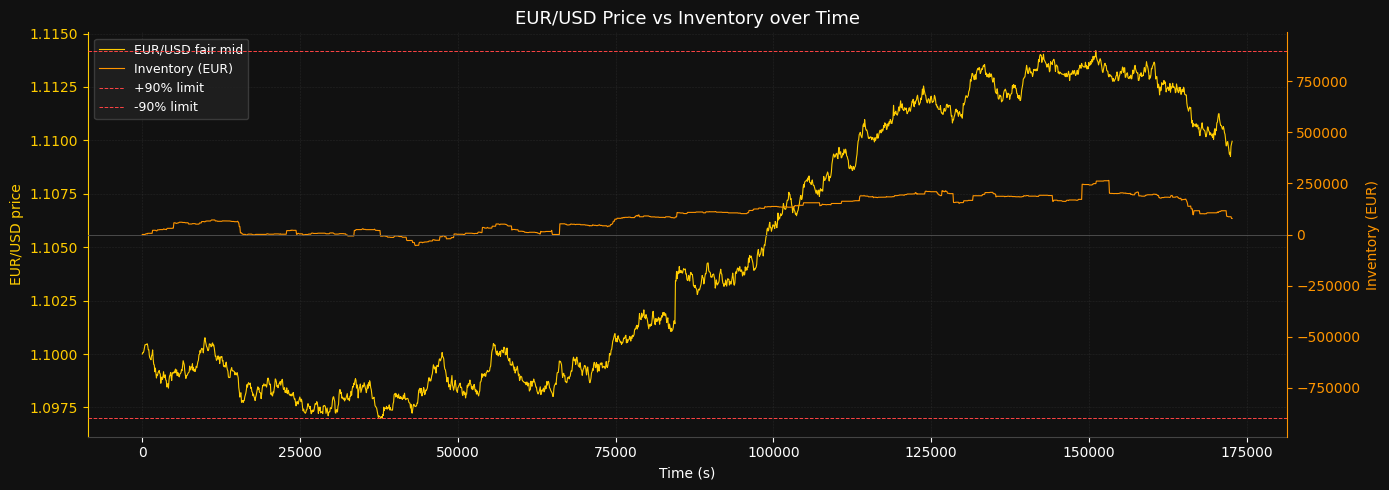

In [6]:
controller.plot_price_inventory()

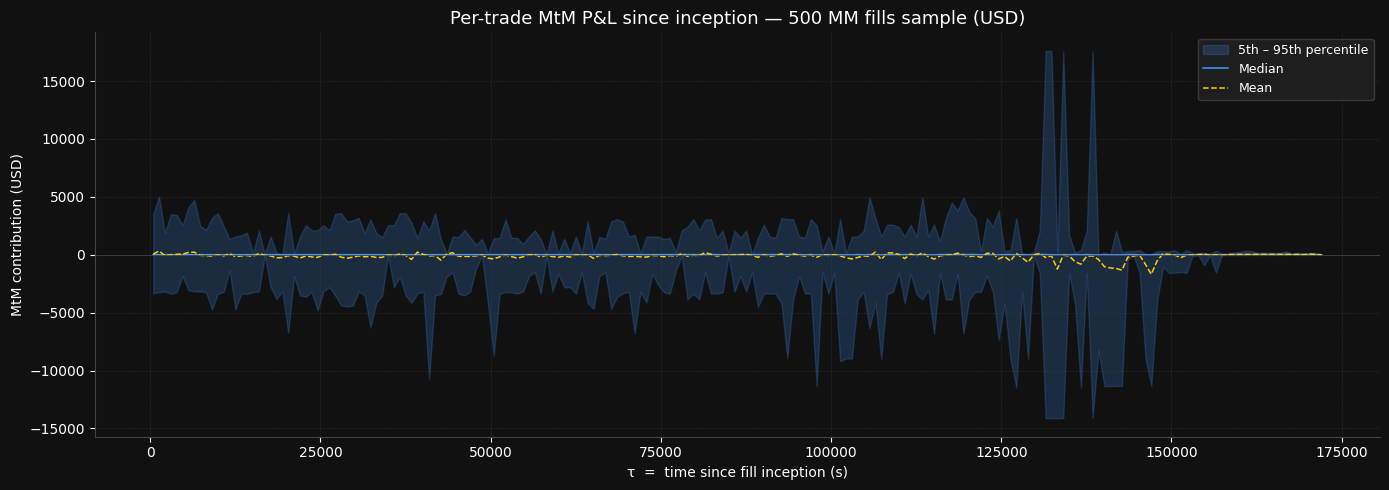

In [7]:
controller.plot_mtm_percentiles()

════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (2.0 days, dt=0.0s, 17,280,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                             +1328.86  USD
    Realized cash P&L                      -85831.94  USD
    Unrealized (open inventory × mid)       +87160.80  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                       +727.16  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                  +853.87  USD
    (mid drift on open EUR position)
  Total fees paid                             252.17  USD
    Maker fees (exchange A)                   252.17  USD
    Taker fees (hedge B/C)                      0.00  USD
────────────────────────────────────────────────────────────────────
  MM fills                                       846  (423/day)
  Hedge legs                                      

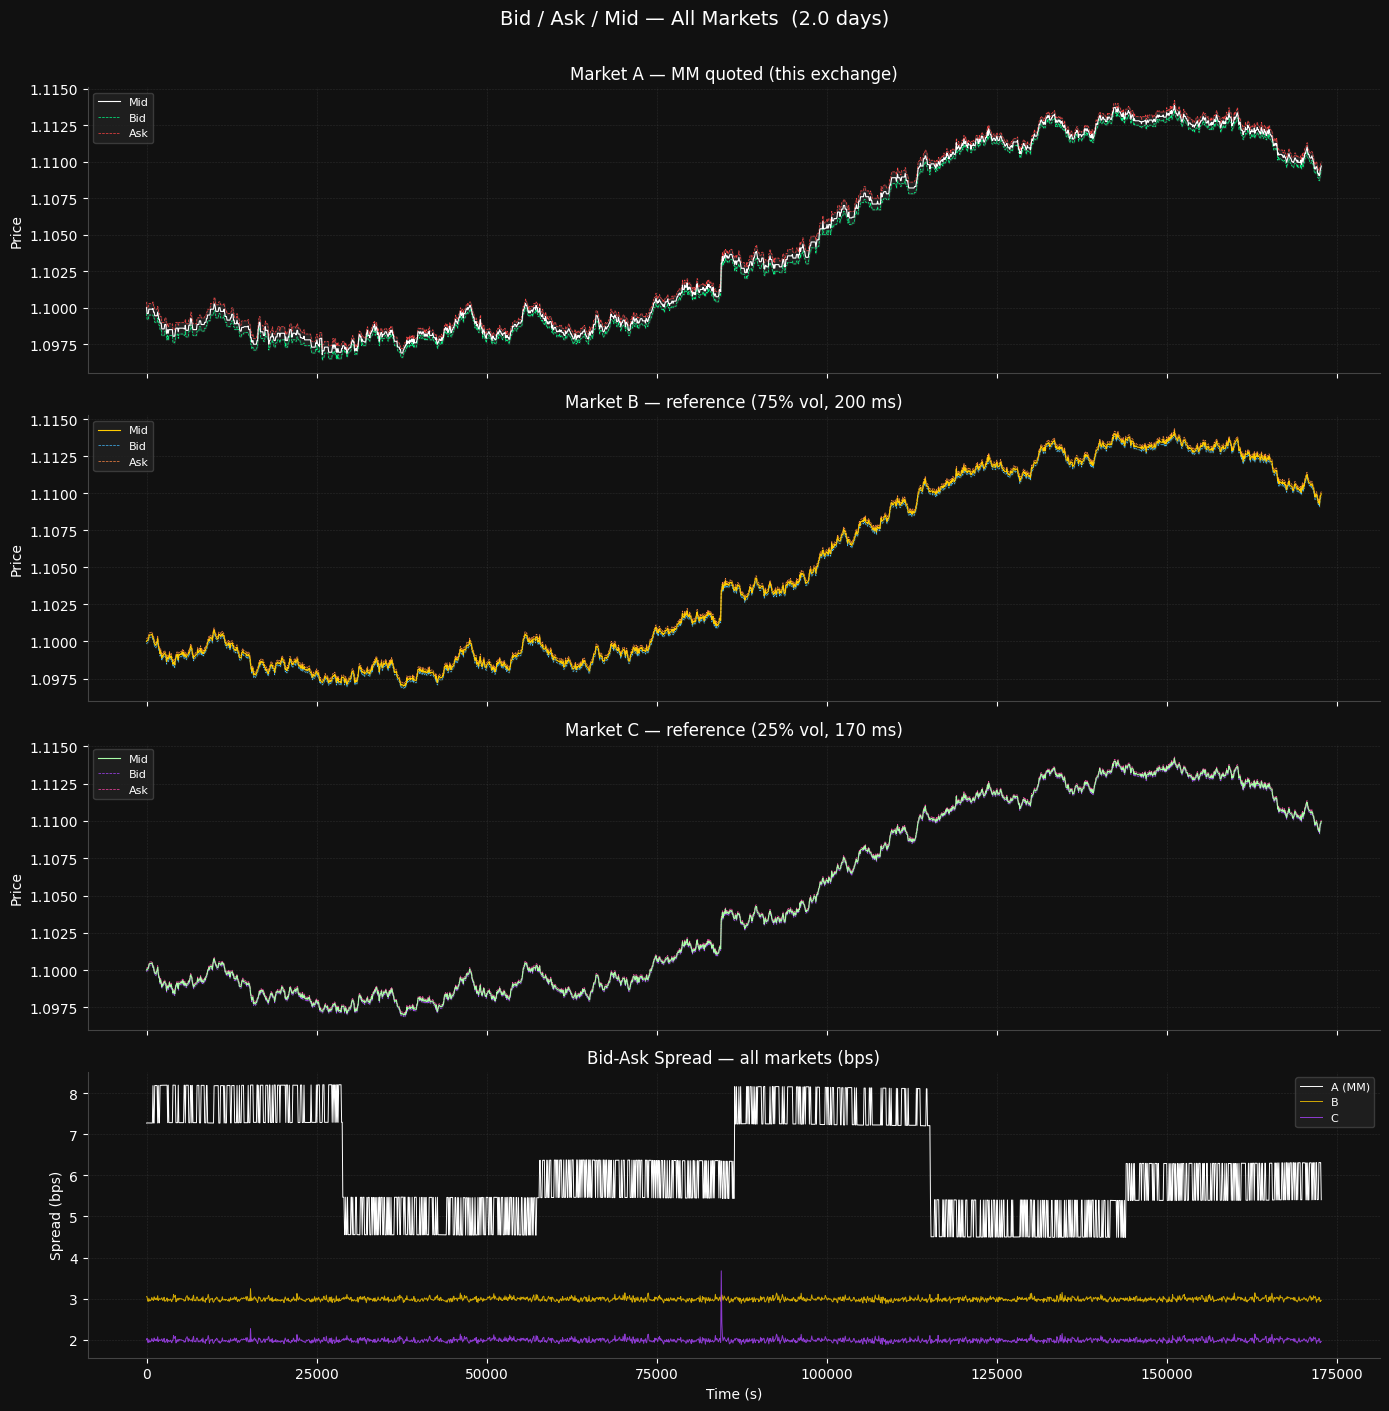

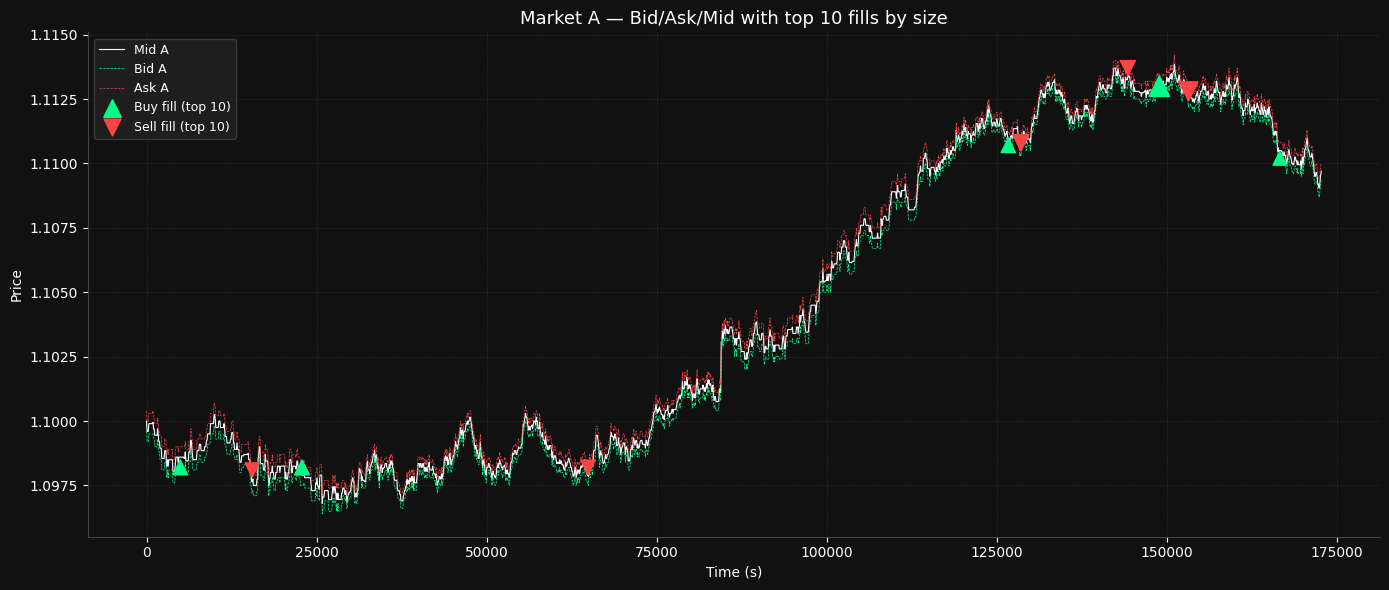

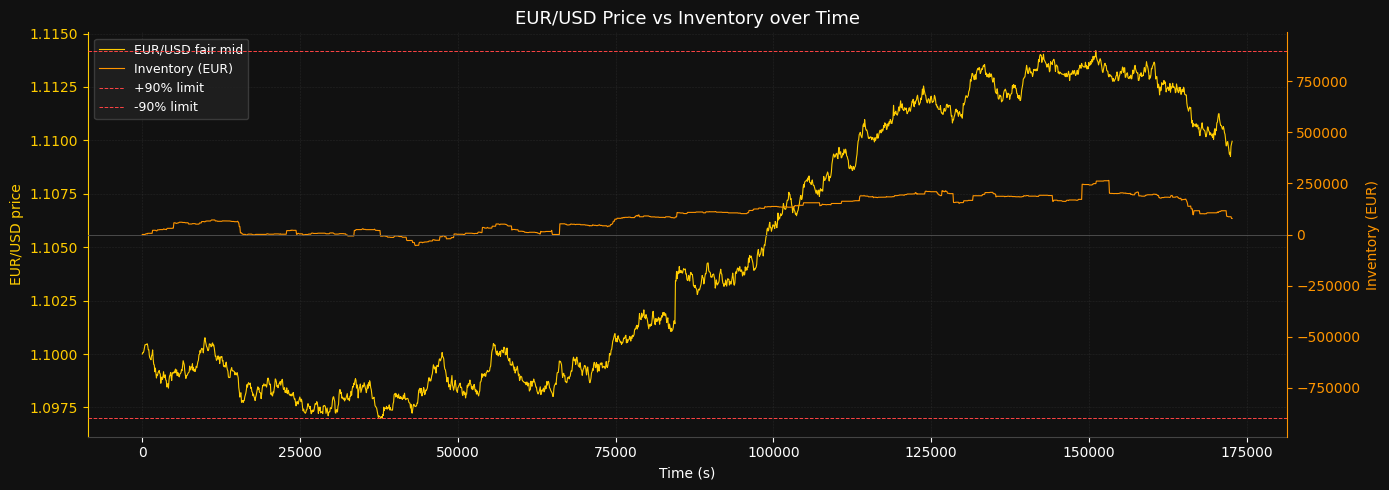

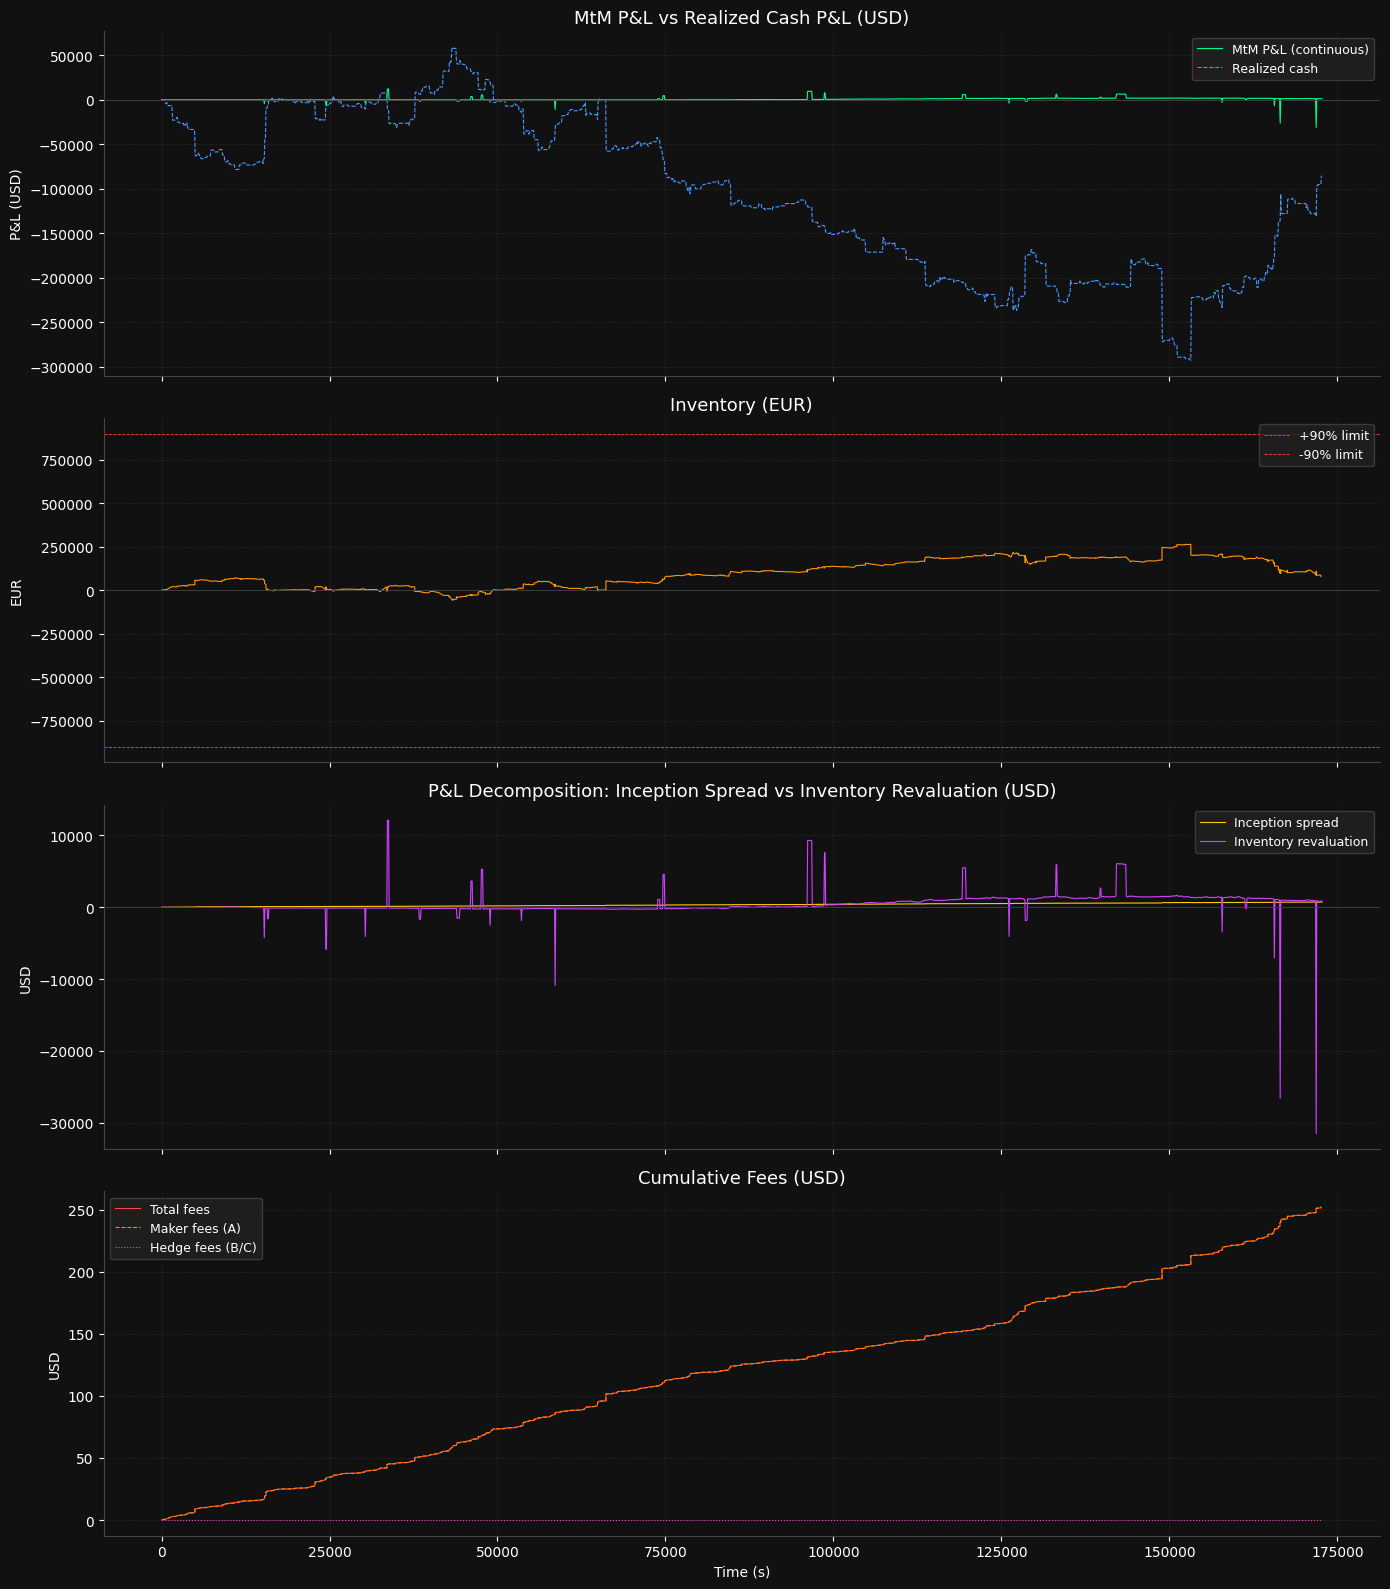

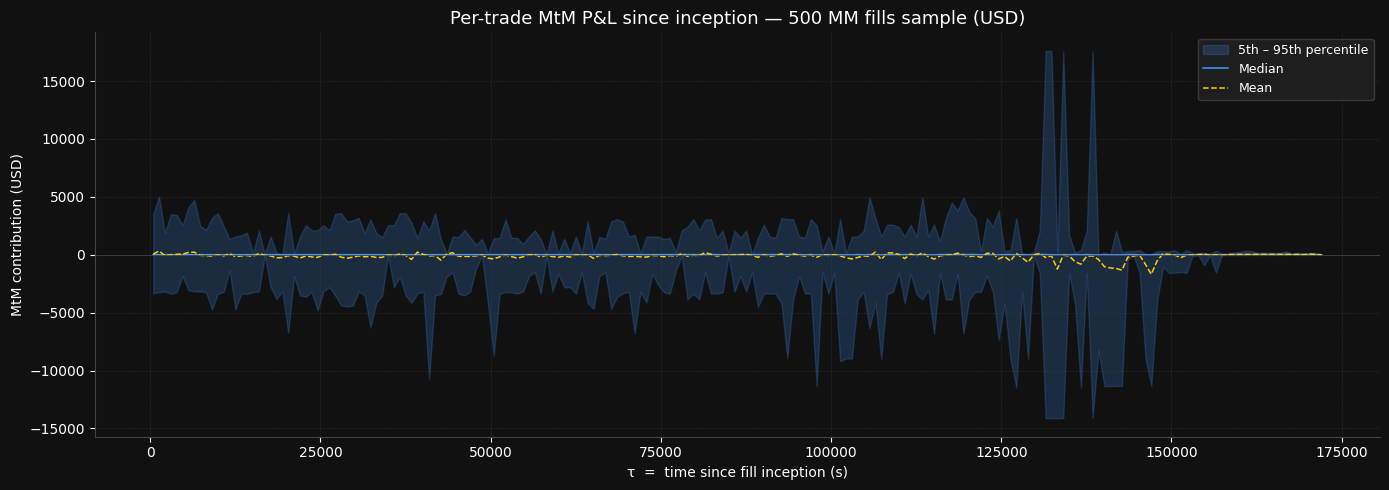

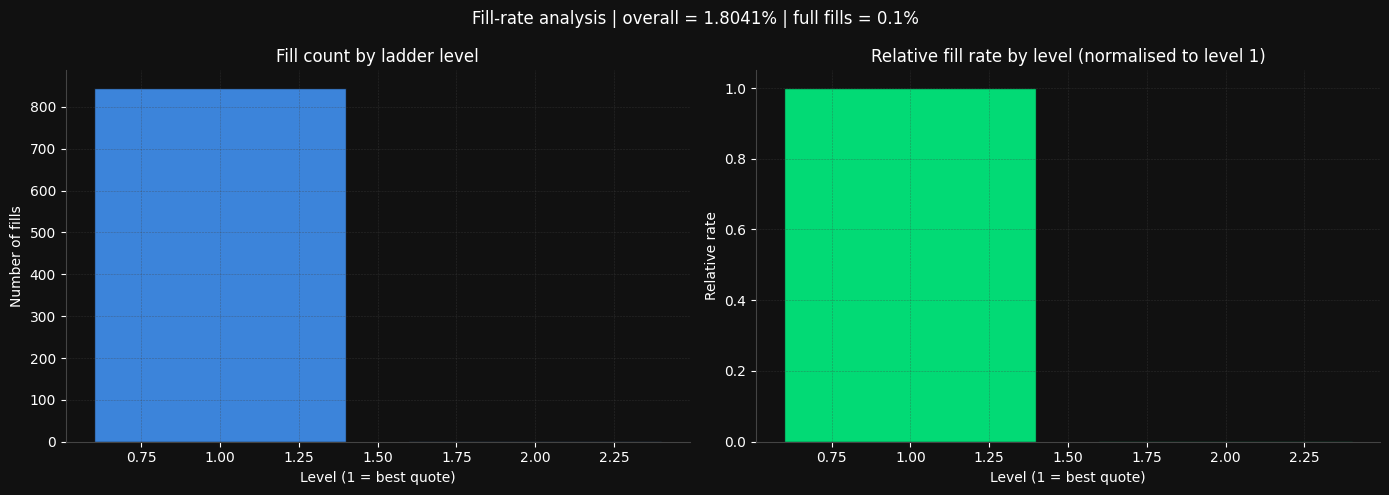

In [8]:
controller.report()